imput neurons = features
output neurons = features
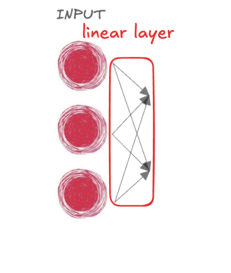


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


In [2]:
input_tensor = torch.tensor(

    [[0.3471,0.4547,-0.2356]]
)

linear_layer = nn.Linear(
    in_features=3,
    out_features=2,
)



In [3]:
output = linear_layer(input_tensor)
output

tensor([[0.3131, 0.2004]], grad_fn=<AddmmBackward0>)

At first, weights and biases are assigned randomly.

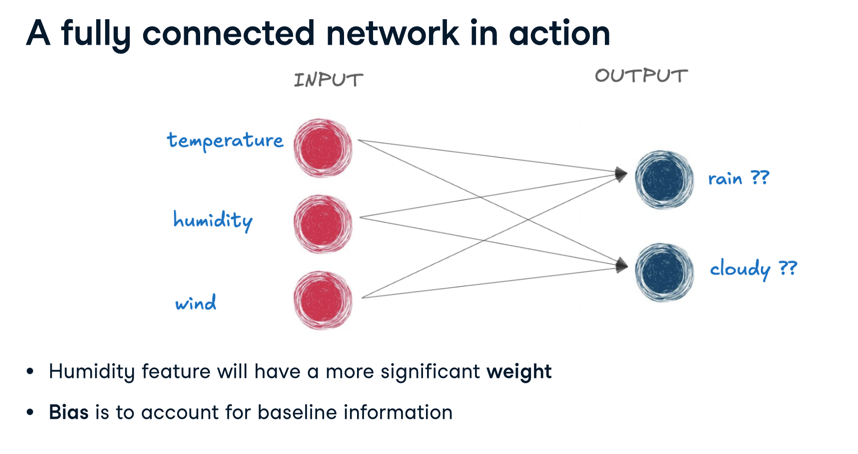

## Hidden Layers
More hidden layers = more parameters = higher model capacity
.numel = returns

fully commected:

In [4]:
model = nn.Sequential

## Activation Functions
They help to add **non linearity** to the network, so that networks can learn complex non linear relationships.
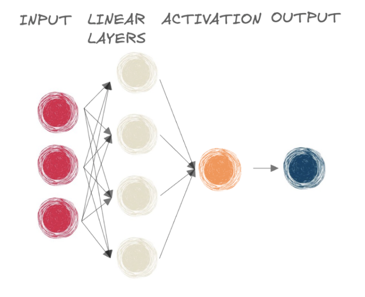

Some types:
* sigmoid : binary classification
* softmax: multi class classification

## Sigmoid Activation Function for Binary Classification

* Sigmoid in last layer of network of linear layers is EQUIVALENT to traditional logistic regression.

* For example, question is to determine whether one animal is mammal ore not
    * input:
        * limbs: 4, eggs:0 , hair:1
        * passing them to a linear layer:
                * 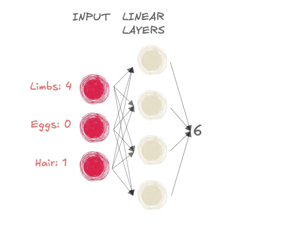
        * after sigmoid we recieve


In [5]:
input_tensor = torch.tensor([[6]]) #6 being here final output of an linear network

sigmoid = nn.Sigmoid()
output = sigmoid(input_tensor)
output


tensor([[0.9975]])

In [6]:
# full model in nn.sequential


model = nn.Sequential(
    nn.Linear(in_features=6, out_features=4),
    nn.Linear(4,1),
    nn.Sigmoid()
)



## Softmax Activation Function for Multiclass Classification

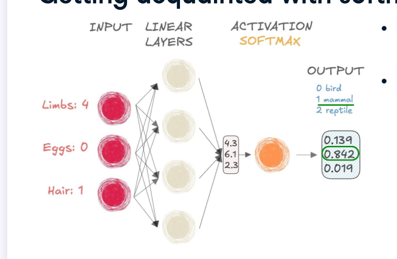

* Output is a probability distrubution
* Each element is a proability between 0 and 1, sum is 1
* Shows how likely it is to belong to a sepcific group

In [7]:
input_tensor = torch.tensor([[4.3,6.1,2.3]])

# dim -1 ensures: applying to the LAST DIMENSION
probabilities = nn.Softmax(dim=-1)
output_tensor = probabilities(input_tensor)
output_tensor


tensor([[0.1392, 0.8420, 0.0188]])

## Running a Forward Pass


In [8]:
# input data for 5 animals and 6 features

input_data_animal = torch.tensor(
    #feature1      #f2     #f3     #f4       #f5     #f6
    [[-0.4421,  1.5207,  2.0607, -0.3647,  0.4691,  0.0946], #animal_1
     [-0.9155, -0.0475, -1.3645,  0.6336, -1.9520, -0.3398], #animal 2
     [ 0.7406,  1.6763, -0.8511,  0.2432,  0.1123, -0.0633], #3
     [-1.6630, -0.0718, -0.1285,  0.5396, -0.0288, -0.8622], #4
     [-0.7413,  1.7920, -0.0883, -0.6685,  0.4745, -0.4245]]) #5

labels_animal = torch.tensor([0, 2, 0, 1, 0])



### Sigmoid Activation Funtion (Binary Classification)
question/ output: is the animal mammal or not. <br>
we recieve 5 different output for 5 different animal

In [9]:
model_sigmoid = nn.Sequential(
    nn.Linear(6, 4), # First linear layer
    nn.Linear(4, 1), # Second linear layer
    nn.Sigmoid() # Sigmoid activation function
)


In [10]:
output = model_sigmoid(input_data_animal)
output #output is probabilities for each animal of being mammal or not

tensor([[0.6267],
        [0.5985],
        [0.7405],
        [0.5976],
        [0.7015]], grad_fn=<SigmoidBackward0>)

### Softmax Activation Funtion
*Parameter takes which dimension is making a specific example, e.g. "unkown creature". dim = -1 is ensuring it is taking the last one.

* for an 2d array,
    * dim = 0 : rows
    * dim = 1 : columns

* but as the normalization is asked there
    *  dim = 1, normalizing OVER COLUMNS, makes the total of every ROW 1.

In [11]:
n_classes = 3 #how many types of animals we have

model_softmax = nn.Sequential(

    nn.Linear(6, 4),
    nn.Linear(4,n_classes),
    nn.Softmax(dim = -1)

)

In [12]:
output = model_softmax(input_data_animal)
output

tensor([[0.3007, 0.2439, 0.4554],
        [0.3898, 0.3026, 0.3075],
        [0.3411, 0.3162, 0.3427],
        [0.3087, 0.2903, 0.4010],
        [0.3277, 0.2856, 0.3867]], grad_fn=<SoftmaxBackward0>)

# Loss Functions

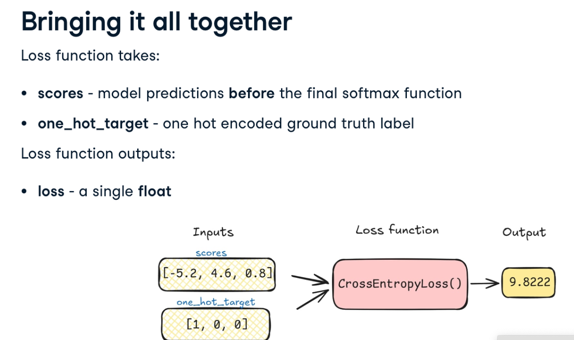


* $y$ = ground truth, real value  y

* $\hat{y}$ = model output, predicted / estimated value of y

* logit : raw scores before SOFTMAX

#### in our classification example/ pytorch logic:

* y is a *single integer*, single *real* value
    * e.g. y= 0 for mammals for y= 1 for birds etc.

* $\hat{y}$ is a TENSOR with N dimensions, N being number of possible classes (mammal, bird)
    * $\hat{y}$ = [-5.2, 4.6, 0.8]

* to calculate loss, we need turn to our ground truth to an tensor of N with one-hot encoding

>y = 0, N = 3  →  [1, 0, 0] <br>
>y = 1, N = 3  →  [0, 1, 0] <br>
>y = 2, N = 3  →  [0, 0, 1]

#### Example Loss Function : Cross Entropy Loss

Standard loss function for **multi-class classification**. Takes logits and ground truth, outputs a single float.

#### Inputs
- **scores (logits)** — raw model output before softmax, e.g. `[-5.2, 4.6, 0.8]`
- **target** — either an integer class index `y = 0` or a one-hot encoded tensor `[1, 0, 0]`

#### What happens internally
CrossEntropyLoss does two things in one step:

1. **Softmax** — converts logits to probabilities
$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

2. **Negative Log Likelihood** — penalizes low probability assigned to the correct class
$$\mathcal{L} = -\log(p_{\text{correct class}})$$

#### implementation
* As CrossEntropyLoss applies softmax internally, it wouldnt be applied added to the network.
* We seperate the network layers for training and inference, using logits 

In [13]:
model_softmax_logit = nn.Sequential(

    nn.Linear(6, 4),
    nn.Linear(4,n_classes)

)

logits = model_softmax_logit(input_data_animal)
logits

tensor([[ 0.0185,  0.2060,  0.2411],
        [-0.2377, -0.1511,  0.2964],
        [-0.4729, -0.0888, -0.2441],
        [-0.2012, -0.0931,  0.4140],
        [-0.5348, -0.1041,  0.0338]], grad_fn=<AddmmBackward0>)

In [14]:
probs = torch.softmax(logits, dim= -1) #same network structure with softmax model is reached, but as the weights are randomly choosen output of both wont be same
probs

tensor([[0.2894, 0.3491, 0.3615],
        [0.2634, 0.2872, 0.4494],
        [0.2684, 0.3941, 0.3374],
        [0.2522, 0.2811, 0.4667],
        [0.2323, 0.3574, 0.4103]], grad_fn=<SoftmaxBackward0>)

In [15]:
#### ONE HOT ENCODING IS NOT EXPECTED FOR CROSS ENTROPY LOSS IMPLEMENTATION! ####
print(labels_animal)

criterion = nn.CrossEntropyLoss()
loss = criterion(logits,labels_animal)
loss


tensor([0, 2, 0, 1, 0])


tensor(1.2168, grad_fn=<NllLossBackward0>)

# Back Propagation

### Remembering: Convex and Nonconvex functions

* Convex: only one global minimum
* non convex: multiple local minimum

* Most neural network loss landscapes are non-convex
by nature. However, in practice, most local minima in large networks yield sufficiently good solutions.

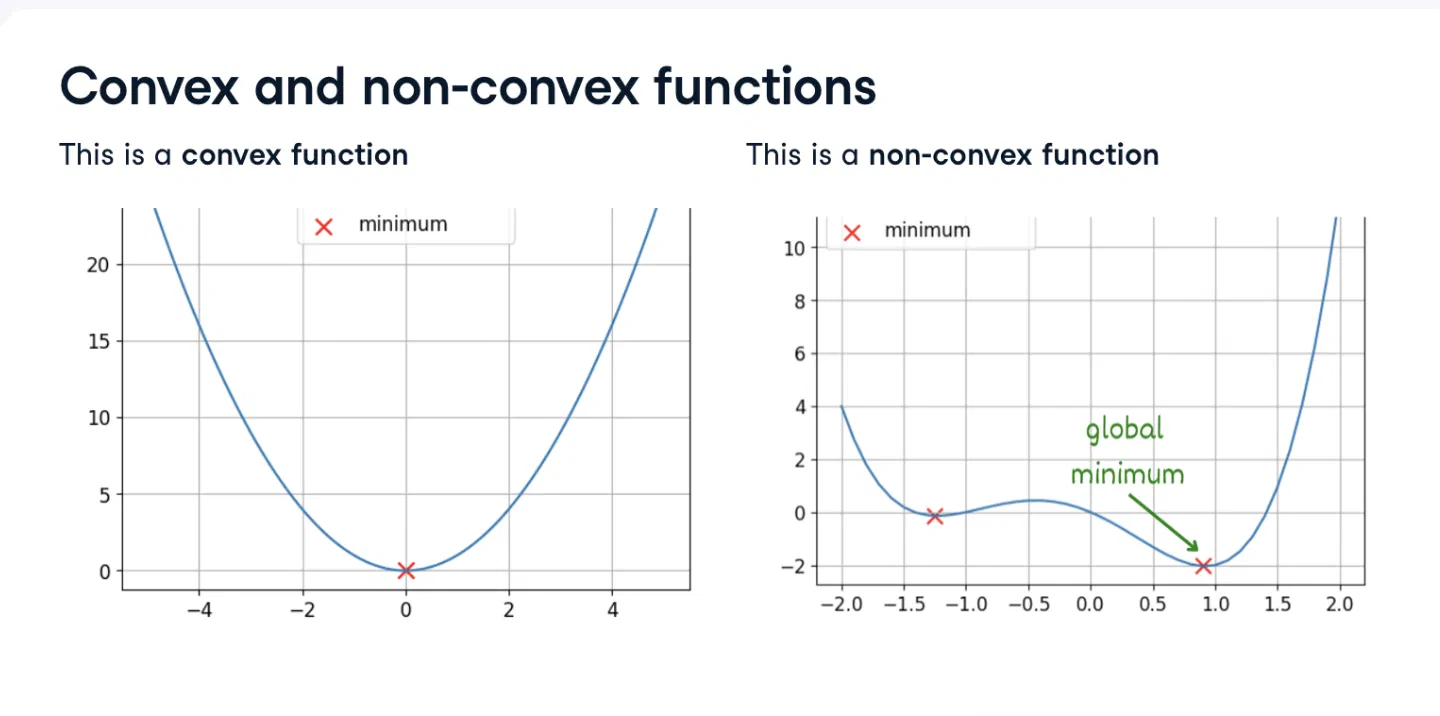

* Taking derivative of an loss function answers:
    *  "If I increase this weight slightly, does the loss increase or decrease, and by how much?"

## Gradient Descent

* The gradient is the generalization of the derivative to multiple dimensions,one partial derivative per weight. It points in the direction of steepest ascent.

* Gradient descent moves in the **opposite direction** of the gradient:

$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}$$

where:
- $w$ is the weight being updated
- $\eta$ is the learning rate, controlling step size
- $\frac{\partial \mathcal{L}}{\partial w}$ is the partial derivative of the loss with respect to $w$

## Backpropagation

Backpropagation is the algorithm used to compute gradients efficiently across all layers.

For a network with layers $L_0, L_1, L_2$:

1. Compute gradients for $L_2$ directly from the loss
2. Use the chain rule to propagate gradients back to $L_1$
3. Repeat for $L_0$

$$\frac{\partial \mathcal{L}}{\partial w_{L_0}} = \frac{\partial \mathcal{L}}{\partial out_{L_2}} \cdot \frac{\partial out_{L_2}}{\partial out_{L_1}} \cdot \frac{\partial out_{L_1}}{\partial w_{L_0}}$$

In PyTorch, `loss.backward()` handles this automatically via the autograd engine,
which records the computation graph during the forward pass.

## Learning Rate Considerations

The learning rate $\eta$ is a critical hyperparameter:

- Too large: updates overshoot the minimum, loss oscillates or diverges
- Too small: convergence is extremely slow
- Well-tuned: smooth, stable descent toward a minimum




In [24]:
loss.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

### Accessing each layers gradients

In [25]:
print(model_softmax_logit[0].weight)
print(model_softmax_logit[0].bias)



Parameter containing:
tensor([[-0.0215,  0.2528, -0.0457,  0.2837,  0.3017, -0.2867],
        [ 0.3295,  0.2923, -0.1671, -0.2184, -0.1508, -0.3685],
        [ 0.3138, -0.0236,  0.3308,  0.3959,  0.2226, -0.1512],
        [ 0.3673, -0.0226, -0.2091, -0.2399, -0.3067, -0.3923]],
       requires_grad=True)
Parameter containing:
tensor([ 0.2342,  0.2694, -0.0673,  0.0060], requires_grad=True)


In [26]:
print(model_softmax_logit[0].weight.grad)
print(model_softmax_logit[0].bias.grad)

tensor([[-0.0052,  0.1806,  0.0739, -0.0429,  0.0896, -0.0120],
        [ 0.0790,  0.0817, -0.0340, -0.0225, -0.0627,  0.0422],
        [ 0.0295, -0.2465, -0.1194,  0.0577, -0.1507,  0.0296],
        [-0.0250, -0.1365, -0.0318,  0.0335, -0.0310, -0.0079]])
tensor([ 0.0883,  0.0167, -0.1270, -0.0585])


### Updating model parameters manually

In [29]:
learning_rate = 0.001

#calculating weights
weight = model_softmax_logit[0].weight
weight_grad = model_softmax_logit[0].weight.grad


new_weight = weight - learning_rate * weight_grad
print(f"old weight= {weight}")
print(f"new weight= {new_weight}")

#calculating biases
bias = model_softmax_logit[0].bias
bias_grad = model_softmax_logit[0].bias.grad
new_bias = bias - learning_rate * bias_grad

print(f"old bias= {bias}")
print(f"new bias= {new_bias}")

# changing model weights

#model_softmax_logit[0].weight.data = new_weight
#model_softmax_logit[0].bias.data = new_bias


old weight= Parameter containing:
tensor([[-0.0215,  0.2528, -0.0457,  0.2837,  0.3017, -0.2867],
        [ 0.3295,  0.2923, -0.1671, -0.2184, -0.1508, -0.3685],
        [ 0.3138, -0.0236,  0.3308,  0.3959,  0.2226, -0.1512],
        [ 0.3673, -0.0226, -0.2091, -0.2399, -0.3067, -0.3923]],
       requires_grad=True)
new weight= tensor([[-0.0214,  0.2527, -0.0458,  0.2838,  0.3016, -0.2867],
        [ 0.3294,  0.2922, -0.1671, -0.2184, -0.1507, -0.3685],
        [ 0.3138, -0.0233,  0.3309,  0.3958,  0.2227, -0.1512],
        [ 0.3674, -0.0224, -0.2091, -0.2400, -0.3066, -0.3923]],
       grad_fn=<SubBackward0>)
old bias= Parameter containing:
tensor([ 0.2342,  0.2694, -0.0673,  0.0060], requires_grad=True)
new bias= tensor([ 0.2341,  0.2694, -0.0671,  0.0061], grad_fn=<SubBackward0>)


# Handling Backpropagation with Optimizers

Fazit: Most people start with Adam, it works well out of the box without much tuning. SGD + momentum can sometimes beat Adam on final accuracy but requires much more careful learning rate and schedule tuning to get there.

An optimizer uses gradients computed by backpropagation to update model weights.
Backpropagation computes the gradients, the optimizer decides how to apply them.

### Example: Vanilla SGD

Updates weights directly using the gradient:

$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}$$

Simple but sensitive to learning rate choice and slow in flat regions.


<generator object Module.parameters at 0x151167060>

In [34]:
optimizer = optim.SGD(model_softmax_logit.parameters(),lr=learning_rate)

optimizer.step()